In [2]:
import tensorflow as tf

print(tf.__version__)

2.21.0


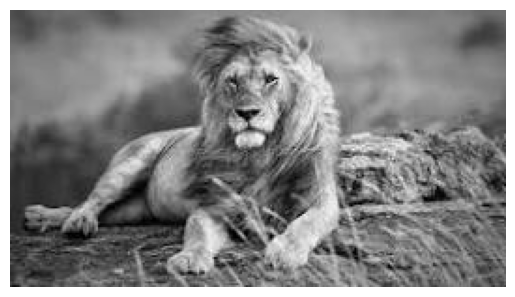

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("content.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [5]:
from tensorflow.keras.applications import VGG19

model = VGG19(weights='imagenet', include_top=False)

print("AI Model Loaded Successfully!")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
AI Model Loaded Successfully!


In [6]:
model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
import os
print(os.listdir())

['content.jpg', 'style.jpg', 'style_transfer.ipynb', 'venv']


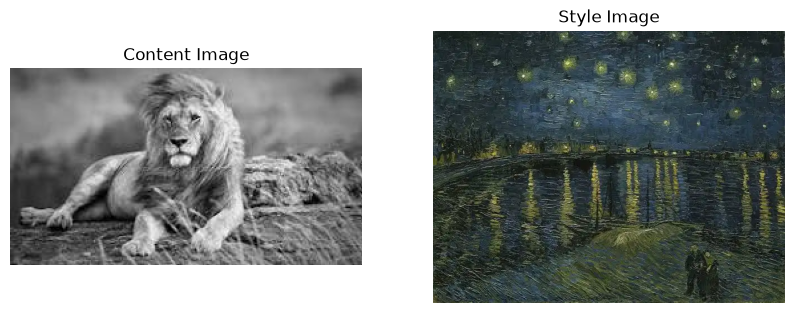

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

content = Image.open("content.jpg")
style = Image.open("style.jpg")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(content)
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(style)
plt.title("Style Image")
plt.axis("off")

plt.show()

In [9]:
from tensorflow.keras.applications import VGG19

model = VGG19(
    weights='imagenet',
    include_top=False
)

print("AI Model Loaded Successfully!")

AI Model Loaded Successfully!


In [10]:
import tensorflow as tf
import numpy as np
from PIL import Image

def load_img(path):
    img = Image.open(path)
    img = img.resize((224,224))
    img = np.array(img)
    img = tf.convert_to_tensor(img)
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)
    return img

content_image = load_img("content.jpg")
style_image = load_img("style.jpg")

print(content_image.shape)
print(style_image.shape)

(1, 224, 224, 3)
(1, 224, 224, 3)


In [11]:
content_features = model(content_image)
style_features = model(style_image)

print("Content Features Shape:")
print(content_features.shape)

print("Style Features Shape:")
print(style_features.shape)

Content Features Shape:
(1, 7, 7, 512)
Style Features Shape:
(1, 7, 7, 512)


In [12]:
generated_image = tf.Variable(content_image)

print(generated_image.shape)

(1, 224, 224, 3)


In [13]:
def content_loss(content, generated):
    return tf.reduce_mean(tf.square(content - generated))

In [14]:
loss = content_loss(content_features, content_features)

print(loss.numpy())

0.0


In [15]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum(
        'bijc,bijd->bcd',
        input_tensor,
        input_tensor
    )

    shape = tf.shape(input_tensor)

    num_locations = tf.cast(
        shape[1] * shape[2],
        tf.float32
    )

    return result / num_locations

In [16]:
style_gram = gram_matrix(style_features)

print(style_gram.shape)

(1, 512, 512)


In [17]:
def style_loss(style, generated):
    return tf.reduce_mean(
        tf.square(
            gram_matrix(style) - gram_matrix(generated)
        )
    )

In [18]:
alpha = 1e4   # Content weight
beta = 1e-2   # Style weight

def total_loss(content_features,
               generated_features,
               style_features):

    c_loss = content_loss(
        content_features,
        generated_features
    )

    s_loss = style_loss(
        style_features,
        generated_features
    )

    return alpha * c_loss + beta * s_loss

In [19]:
optimizer = tf.optimizers.Adam(
    learning_rate=5.0
)

In [20]:
@tf.function
def train_step(image):

    with tf.GradientTape() as tape:

        generated_features = model(image)

        loss = total_loss(
            content_features,
            generated_features,
            style_features
        )

    grad = tape.gradient(
        loss,
        image
    )

    optimizer.apply_gradients(
        [(grad, image)]
    )

    image.assign(
        tf.clip_by_value(
            image,
            0.0,
            255.0
        )
    )

    return loss

In [21]:
generated_image = tf.Variable(content_image)

for i in range(20):

    loss = train_step(
        generated_image
    )

    print(
        f"Step {i+1}, Loss = {loss.numpy():.2f}"
    )

Step 1, Loss = 14.17
Step 2, Loss = 841070.31
Step 3, Loss = 631457.06
Step 4, Loss = 423492.47
Step 5, Loss = 321241.19
Step 6, Loss = 262173.75
Step 7, Loss = 222705.73
Step 8, Loss = 167858.62
Step 9, Loss = 152824.45
Step 10, Loss = 129779.27
Step 11, Loss = 119709.52
Step 12, Loss = 105406.34
Step 13, Loss = 98129.09
Step 14, Loss = 90729.20
Step 15, Loss = 83166.11
Step 16, Loss = 76408.38
Step 17, Loss = 71927.50
Step 18, Loss = 67334.41
Step 19, Loss = 63668.72
Step 20, Loss = 60494.36


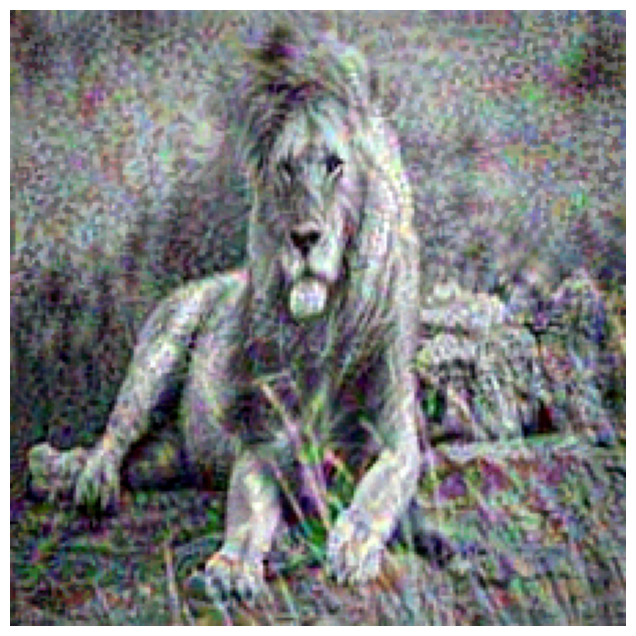

In [22]:
result = generated_image.numpy()[0]

result = result.astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(result)
plt.axis("off")
plt.show()

In [23]:
from PIL import Image
import numpy as np

result = generated_image.numpy()[0]
result = np.clip(result, 0, 255).astype(np.uint8)

Image.fromarray(result).save("output.jpg")

print("Output saved successfully!")

Output saved successfully!


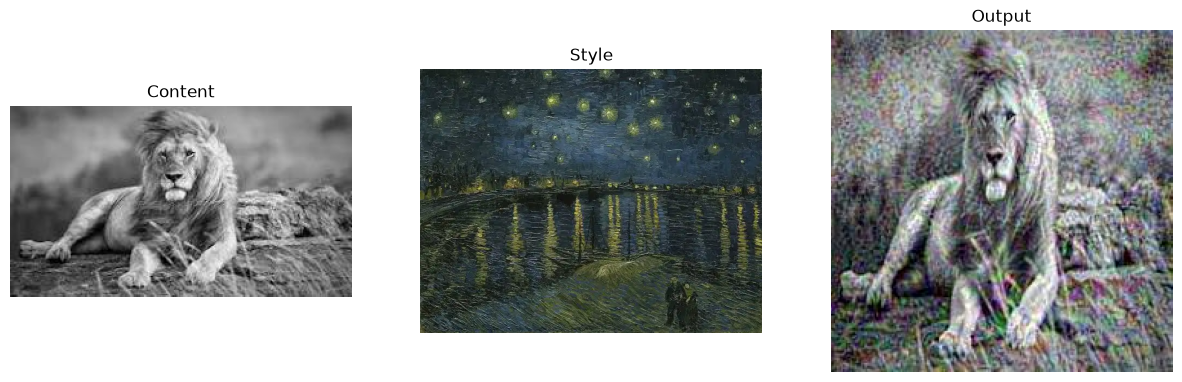

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

content = Image.open("content.jpg")
style = Image.open("style.jpg")
output = Image.open("output.jpg")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(content)
plt.title("Content")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(style)
plt.title("Style")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Output")
plt.axis("off")

plt.show()